
<div style="border-left: 8px solid #1A365D; border-right: 2px solid #E2E8F0; border-top: 2px solid #E2E8F0; border-bottom: 2px solid #E2E8F0; padding: 25px; border-radius: 4px; background-color: #F8FAFC; font-family: 'Segoe UI', Arial, sans-serif; box-shadow: 0 4px 6px -1px rgba(0, 0, 0, 0.05);">
    <span style="color: #D69E2E; font-weight: bold; letter-spacing: 1.5px; font-size: 0.9em; text-transform: uppercase;">FES Acatlán • UNAM</span>
    <h1 style="color: #1A365D; font-size: 2.2em; font-weight: 700; margin-top: 5px; margin-bottom: 5px; line-height: 1.2;">Diplomado en Técnicas Estadísticas y Minería de Datos</h1>
    <h3 style="color: #4A5568; font-size: 1.3em; font-weight: 400; margin-top: 0; margin-bottom: 20px;">Módulo II: Modelos Estadísticos</h3>
    <hr style="border: 0; height: 1px; background: #CBD5E0; margin-bottom: 20px;">
    <table style="width: 100%; border-collapse: collapse; font-size: 0.95em; color: #4A5568;">
        <tr>
            <td style="padding: 4px 0; width: 50%;"><strong>Notebook:</strong> Enfoques de la Teoría de la Probabilidad y Simulación</td>
            <td style="padding: 4px 0; width: 50%; text-align: right;"><strong>Estudiante:</strong> Blanca Sánchez Germán</td>
        </tr>
        <tr>
            <td style="padding: 4px 0;"><strong>Profesora:</strong> Act. Claudia C. Reyes Montes de Oca</td>
            <td style="padding: 4px 0; text-align: right;"><strong>Fecha:</strong> 17 de Junio 2026</td>
        </tr>
    </table>
</div>


## 1. Probabilidad Frecuentista 

Este enfoque define la probabilidad a partir de la experimentación empírica repetida. Formulada originalmente por **Jacob Bernoulli**, la **Ley de los Grandes Números** establece que si realizamos un experimento independiente un número extremadamente grande de veces, la **frecuencia relativa** de un evento $A$ convergerá casi con total certeza a su **probabilidad teórica** $P(A)$.

### Formulación Matemática
La frecuencia relativa $f_n(A)$ se define como:
$$f_n(A) = \frac{n(A)}{n}$$

Donde:
* $n(A)$ es el número de veces que el evento $A$ ocurre en las repeticiones.
* $n$ es el número total de ensayos o experimentos.

El postulado frecuentista afirma que:
$$\lim_{n \to \infty} f_n(A) = P(A)$$


Sea el experimento aletrorio de lanzar una moneda (no junta ) 

In [4]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import random # para generar números aleatorios
def volado(p):
    return "sol" if random.random() < p else "aguila"
# random.random() genera un numero entre 0 y 1
    

In [3]:
volado(0.4) #hay un 40% de obtener sol

'aguila'

In [9]:
#vamos a realizar 10 volador con probabilidad p
#range(n) crea un contador que va del 0 al 9 (repite n veces)
vol = [volado(0.4) for i in range(10)]
vol

['aguila',
 'aguila',
 'sol',
 'aguila',
 'aguila',
 'aguila',
 'aguila',
 'sol',
 'aguila',
 'aguila']

In [10]:
#Para contar el numero de soles en una lsita 
vol.count("sol")

2

In [11]:
#Para contar el numero de aguilas
vol.count("aguila")

8

Vamos a simular la probabilidad frecuentista, es decir, vamos a realizar un experimento con 1000 volados (individual) y puede repetir 500 veces (500 personas)

In [12]:
#Creamos una lista para almacenar las probabilides
p = []

for i in range(500): # 500 experimentos
    N = 1000 # cada experimiento tiene 1000 volados
    resultados = [] # se alamacenan "sol" o "águila"
    
    for j in range(N):
        resultado = volado(0.63)
        resultados.append(resultado)
        
    n_soles = resultados.count("sol")
    p_soles = n_soles / N #prob frecuentista
    
    #Añadimos estas probabilidades a la lista p
    p.append(p_soles)

    #Probabilidad frect. promedio
    
p_soles_prom = sum(p) / 500

p_soles_prom


0.629876

In [5]:
#Simulación de un Dado Cargado 
def lanzar_dado_cargado():
    """Simula un dado de 6 caras donde el '6' está cargado (Probabilidad de 30%)"""
    caras = [1, 2, 3, 4, 5, 6]
    # El 6 tiene 0.30, las otras 5 caras se reparten el 0.70 restante (0.14 cada una)
    probabilidades = [0.14, 0.14, 0.14, 0.14, 0.14, 0.30]
    return np.random.choice(caras, p=probabilidades)

print(f"Resultado de un dado cargado: {lanzar_dado_cargado()}")

Resultado de un dado cargado: 1


### Ejemplo: El Control de Calidad en una Fábrica de Componentes

Una planta de manufactura automatizada produce componentes tecnológicos de alta precisión de forma continua. El equipo de auditoría interna de calidad necesita estimar con precisión la probabilidad real de que un componente salga defectuoso de la línea de ensamble para calcular los costos esperados por garantías.

Para simular este escenario sin alterar el flujo original de nuestro análisis:
1. Asumimos una probabilidad real oculta (media poblacional $\mu = 0.02$).
2. Estructuramos la auditoría dividiendo la producción masiva en **500 lotes** independientes.
3. Cada lote es inspeccionado minuciosamente con una muestra de **1,000 componentes**.

A través de la Ley de los Grandes Números, el promedio de las frecuencias relativas de estos 500 experimentos (media muestral $\bar{x}$) convergerá casi con total certeza hacia la probabilidad real del sistema, demostrando cómo la recopilación de datos histórica mitiga la incertidumbre en los procesos operativos.

In [21]:
def inspeccionar_disco(p_defectuoso):
    """Simula la revisión de un disco duro. Retorna 'defectuoso' con probabilidad p_defectuoso"""
    if random.random() < p_defectuoso:
        return "defectuoso"
    else:
        return "funcional"

# Prueba univariada (Un solo disco con 2% de probabilidad de fallo)
p_teorica_defectuoso = 0.02
print(f"Resultado de una inspección: {inspeccionar_disco(p_teorica_defectuoso)}")

# Experimento corto (Lote de 10 discos)
lote_corto = [inspeccionar_disco(p_teorica_defectuoso) for i in range(10)]
print(f"Resultado del lote de 10: {lote_corto}")
print(f"Frecuencia relativa de defectuosos en el lote corto: {lote_corto.count('defectuoso') / 10}\n")


Resultado de una inspección: funcional
Resultado del lote de 10: ['funcional', 'funcional', 'funcional', 'funcional', 'funcional', 'funcional', 'funcional', 'funcional', 'funcional', 'funcional']
Frecuencia relativa de defectuosos en el lote corto: 0.0



In [20]:
# Simulamos 500 lotes de producción, donde cada lote tiene 1,000 discos duros
n_lotes = 500
n_discos_por_lote = 1000

experimentos_calidad = []

for lote in range(n_lotes):
    # Contamos cuántos discos defectuosos salen en este lote de 1,000
    defectuosos = sum(1 for i in range(n_discos_por_lote) if inspeccionar_disco(p_teorica_defectuoso) == "defectuoso")
    frecuencia_relativa_lote = defectuosos / n_discos_por_lote
    experimentos_calidad.append(frecuencia_relativa_lote)

# Sacamos la media muestral empírica (el promedio de los 500 experimentos)
# Representa nuestra aproximación a la media poblacional teórica (\mu)
p_defectuosos_prom = sum(experimentos_calidad) / len(experimentos_calidad)

print(f"Promedio de las frecuencias relativas en los {n_lotes} lotes: {p_defectuosos_prom:.6f}")

Promedio de las frecuencias relativas en los 500 lotes: 0.019950


# Probabilidad Geómetrica 

La probabilidad geométrica extiende el concepto clásico de Laplace a **espacios muestrales infinitos y continuos**, donde el conteo discreto de casos ya no es posible. En su lugar, la probabilidad se calcula como una proporción de magnitudes geométricas: **longitudes, áreas o volúmenes**.

### Formulación Matemática
Si $\Omega$ es un espacio muestral continuo que representa una región geométrica (en $\mathbb{R}$, $\mathbb{R}^2$ o $\mathbb{R}^3$) y $A$ es un evento que corresponde a una subregión de $\Omega$, la probabilidad de que ocurra el evento $A$ se define como:

$$P(A) = \frac{\text{ $\mu$ }(A)}{\text{ $\mu$ }(\Omega)}$$

Donde la "Medida" representa la longitud, área o volumen según la dimensión del problema.

## Ejemplo 1: Problema del encuentro

Dos personas planean encontrarse en un lugar especifico, en un rango de una hora $[0,60]$ minutos (1 hora).
  - Si $A$ llega primero, entonces piensa esperar 10 minutos.
  - Si $B$ llega primero, entonces piensa esperar 10 minutos.

Se elige un número al azar entre $[0,60]$ y supongamos que el par de números se elige sobre el cuadro de modo que la probabilidad de un evento sea el área favorable entre el área total.

Sea: 
- $A$: las dos personas se encunetran a una distancia de 10 minutos
  
Nos gustaría encontrar la probabilidad $A$.

    


La probabilidad del evento A es: 0.3026.


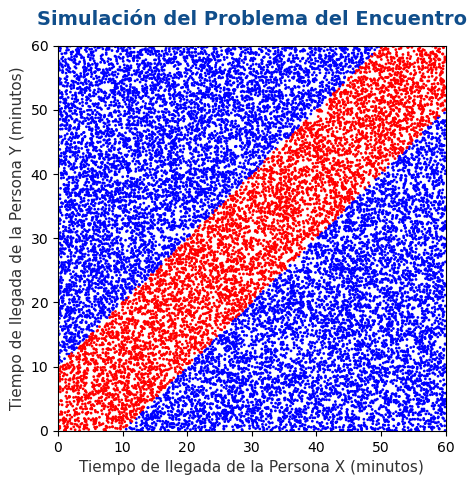

In [19]:
import numpy as np
import matplotlib.pyplot as plt # para gráficos

# Vamos a generar 1000 situaciones
muestra = 20000

# Generamos los tiempos aleatorios entre [0,60]
x = np.random.uniform(0, 60, muestra) # numero aleatorio
y = np.random.uniform(0, 60, muestra)

# Añadimos una condición de encuentro
encuentro = np.where(abs(x-y) <= 10, 'r', 'b') # rojo si encuentran, azul si no.

# Ahora calculamos la probabilidad de que se encuentren
k = 0
for elemento in encuentro:
    if elemento == 'r': # Los favorables
        k += 1 # La añada
        
print("La probabilidad del evento A es: {}.".format(k/muestra))

# Graficamos
plt.figure(figsize=(5,5)) # Tamaño de la figura
plt.scatter(x, y, c=encuentro, s=1)
# Título principal
plt.title("Simulación del Problema del Encuentro", fontsize=14, fontweight='bold', color='#104E8B', pad=15)

# Títulos de ejes
plt.xlabel("Tiempo de llegada de la Persona X (minutos)", fontsize=11, color='#333333')
plt.ylabel("Tiempo de llegada de la Persona Y (minutos)", fontsize=11, color='#333333')

# Ajustamos los límites de los ejes exactos de 0 a 60 para que se vea limpio
plt.xlim(0, 60)
plt.ylim(0, 60)
plt.show()


## Ejemplo 2: El Tiro al Blanco (Regiones Concéntricas en $\mathbb{R}^2$)
Consideremos una diana circular de radio $R = 60$ cm. El centro de la diana contiene un círculo concéntrico de éxito (el "blanco") con un radio de $r = 10$ cm. Si un dardo impacta al azar en cualquier punto de la diana de forma uniformemente distribuida, el espacio muestral $\Omega$ es el área total del círculo mayor y el evento $A$ es el círculo menor.

* **Área de $\Omega$:** $\pi \times R^2 = \pi \times 60^2 = 3,600\pi$
* **Área de $A$:** $\pi \times r^2 = \pi \times 10^2 = 100\pi$
* **Probabilidad Teórica:** 
$$P(A) = \frac{100\pi}{3,600\pi} = \frac{100}{3,600} \approx 0.0277 \quad (2.77\%)$$

In [12]:
# Parámetros globales
n_simulaciones = 10000
np.random.seed(42)

radio_max = 60
radio_blanco = 10

# Generar puntos aleatorios en un cuadrado contenedor [-60, 60]
x_dardos = np.random.uniform(-radio_max, radio_max, n_simulaciones)
y_dardos = np.random.uniform(-radio_max, radio_max, n_simulaciones)

# Filtrar solo los puntos que caen dentro del círculo de la diana (Espacio Muestral Omega)
dentro_blanca = (x_dardos**2 + y_dardos**2) <= radio_max**2
x_blanca = x_dardos[dentro_blanca]
y_blanca = y_dardos[dentro_blanca]

# Evaluar cuáles de esos impactos cayeron en el blanco (Evento A)
en_blanco = (x_blanca**2 + y_diana**2) <= radio_blanco**2
prob_dardo_simulada = np.sum(en_blanco) / len(x_blanca)
prob_dardo_teorica = (radio_blanco**2) / (radio_max**2)
print(f"Prob. Simulada: {prob_dardo_simulada:.4f}\nProb. Teórica: {prob_dardo_teorica:.4f}")

Prob. Simulada: 0.0309
Prob. Teórica: 0.0278


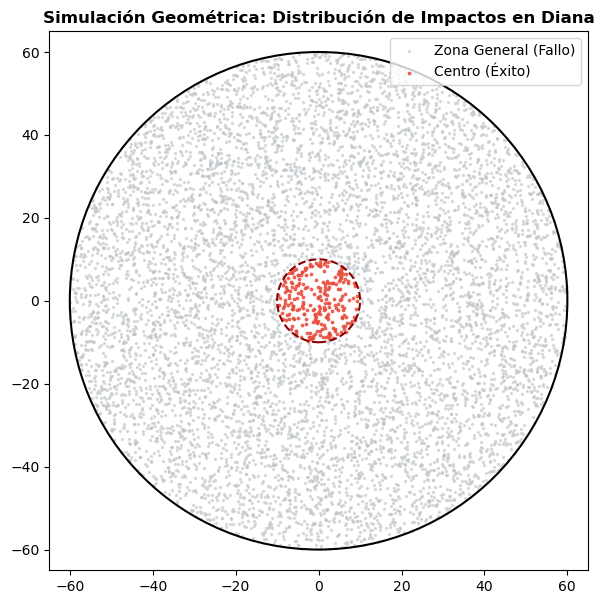

In [17]:
plt.figure(figsize=(7, 7))

# Graficar los puntos de la diana
plt.scatter(x_blanca[~en_blanco], y_blanca[~en_blanco], color='#BDC3C7', alpha=0.5, s=2, label='Zona General (Fallo)')
plt.scatter(x_blanca[en_blanco], y_blanca[en_blanco], color='#E74C3C', alpha=0.8, s=3, label='Centro (Éxito)')

# Dibujar la estructura concéntrica teórica
circulo_exterior = plt.Circle((0, 0), radio_max, color='black', fill=False, lw=1.5, linestyle='-')
circulo_interior = plt.Circle((0, 0), radio_blanco, color='darkred', fill=False, lw=1.5, linestyle='--')
plt.gca().add_patch(circulo_exterior)
plt.gca().add_patch(circulo_interior)

plt.title("Simulación Geométrica: Distribución de Impactos en Diana", fontsize=12, fontweight='bold')
plt.xlim(-radio_max - 5, radio_max + 5)
plt.ylim(-radio_max - 5, radio_max + 5)
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(loc="upper right")
plt.show()